# 01 — EDA & Tabular Preprocessing
Load the raw Ames Housing CSV, explore it visually, then run the full preprocessing pipeline.

## 1.1 — Environment Setup

In [2]:
import sys, os
sys.path.insert(0, os.path.abspath("../src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns

from preprocess import (
    load_data, drop_high_null_cols, fill_missing,
    get_column_types, encode_categoricals, scale_numerics,
    preprocess_pipeline, save_artifacts
)

# Reproducibility
np.random.seed(42)
sns.set_theme(style="whitegrid")
print("Setup complete.")

Setup complete.


# 1.2 — Loading data

In [3]:
RAW_CSV = "../data/raw/train.csv"

df_raw = load_data(RAW_CSV)
print(f"Shape : {df_raw.shape}")
df_raw.head()

[load_data] Loaded 1460 rows × 81 cols from '../data/raw/train.csv'
Shape : (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## 1.3 — Basic Statistics

In [4]:
print("Dtypes:")
print(df_raw.dtypes.value_counts())
print()
df_raw.describe().T.style.background_gradient(cmap="Blues", subset=["mean", "std"])

Dtypes:
str        43
int64      35
float64     3
Name: count, dtype: int64



,count,mean,std,min,25%,50%,75%,max
Id,1460.000000,730.500000,421.610009,1.000000,365.750000,730.500000,1095.250000,1460.000000
MSSubClass,1460.000000,56.897260,42.300571,20.000000,20.000000,50.000000,70.000000,190.000000
LotFrontage,1201.000000,70.049958,24.284752,21.000000,59.000000,69.000000,80.000000,313.000000
LotArea,1460.000000,10516.828082,9981.264932,1300.000000,7553.500000,9478.500000,11601.500000,215245.000000
OverallQual,1460.000000,6.099315,1.382997,1.000000,5.000000,6.000000,7.000000,10.000000
OverallCond,1460.000000,5.575342,1.112799,1.000000,5.000000,5.000000,6.000000,9.000000
YearBuilt,1460.000000,1971.267808,30.202904,1872.000000,1954.000000,1973.000000,2000.000000,2010.000000
YearRemodAdd,1460.000000,1984.865753,20.645407,1950.000000,1967.000000,1994.000000,2004.000000,2010.000000
MasVnrArea,1452.000000,103.685262,181.066207,0.000000,0.000000,0.000000,166.000000,1600.000000
BsmtFinSF1,1460.000000,443.639726,456.098091,0.000000,0.000000,383.500000,712.250000,5644.000000


## 1.4 — Missing Value Heatmap

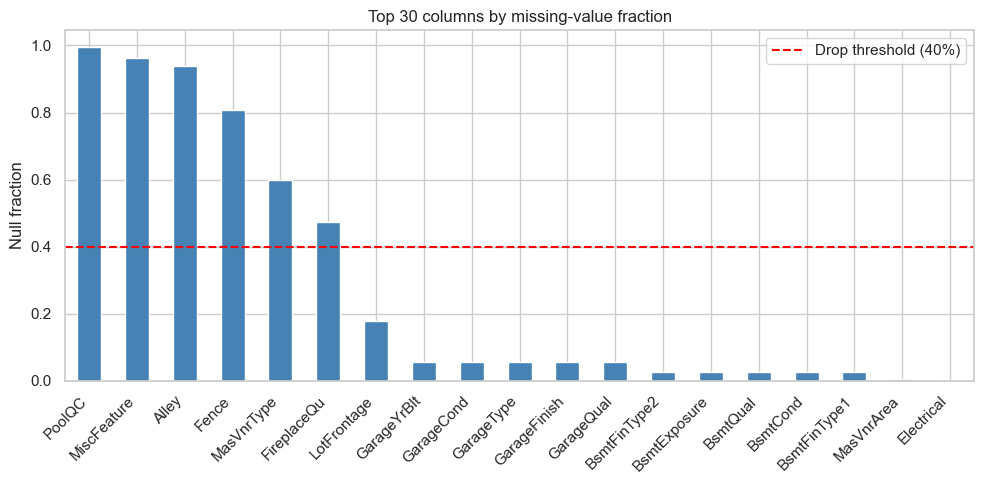

In [5]:
null_pct = df_raw.isnull().mean().sort_values(ascending=False)
null_pct_top = null_pct[null_pct > 0].head(30)

fig, ax = plt.subplots(figsize=(10, 5))
null_pct_top.plot(kind="bar", ax=ax, color="steelblue")
ax.axhline(0.40, color="red", linestyle="--", linewidth=1.5, label="Drop threshold (40%)")
ax.set_ylabel("Null fraction")
ax.set_title("Top 30 columns by missing-value fraction")
ax.legend()
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("../outputs/plots/null_heatmap.png", dpi=120)
plt.show()

## 1.5 — Target Distribution (SalePrice)

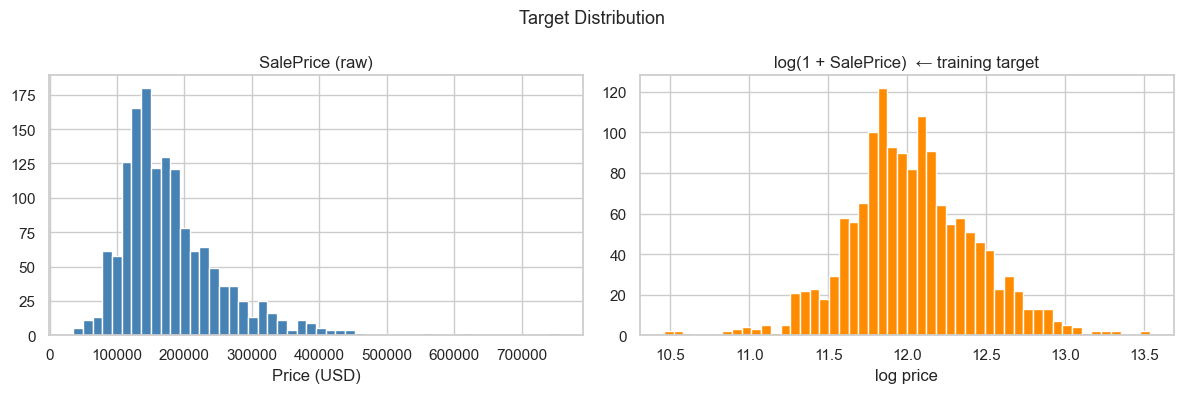

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Raw price
axes[0].hist(df_raw["SalePrice"], bins=50, color="steelblue", edgecolor="white")
axes[0].set_title("SalePrice (raw)")
axes[0].set_xlabel("Price (USD)")

# Log-transformed
axes[1].hist(np.log1p(df_raw["SalePrice"]), bins=50, color="darkorange", edgecolor="white")
axes[1].set_title("log(1 + SalePrice)  ← training target")
axes[1].set_xlabel("log price")

plt.suptitle("Target Distribution", fontsize=13)
plt.tight_layout()
plt.savefig("../outputs/plots/target_distribution.png", dpi=120)
plt.show()

## 1.6 — Correlation with SalePrice (Top 15 Numerics)

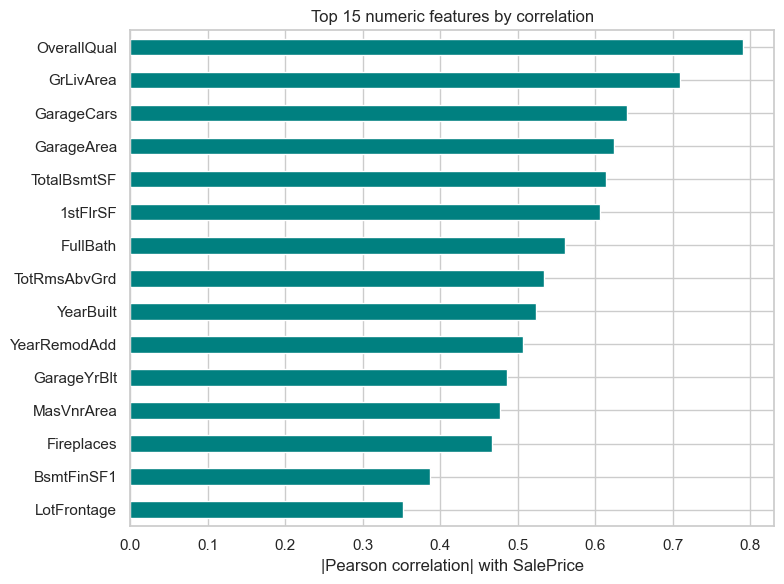

In [7]:
num_cols_raw = df_raw.select_dtypes(include=[np.number]).columns.tolist()
corr = df_raw[num_cols_raw].corr()["SalePrice"].drop("SalePrice").abs().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
corr.head(15).plot(kind="barh", ax=ax, color="teal")
ax.set_xlabel("|Pearson correlation| with SalePrice")
ax.set_title("Top 15 numeric features by correlation")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("../outputs/plots/feature_correlation.png", dpi=120)
plt.show()

## 1.7 — Run Full Preprocessing Pipeline

In [8]:
result = preprocess_pipeline(RAW_CSV)

X         = result["X"]
y         = result["y"]
y_raw     = result["y_raw"]
scaler    = result["scaler"]
encoders  = result["encoders"]
qual_vals = result["qual_values"]

[load_data] Loaded 1460 rows × 81 cols from '../data/raw/train.csv'
[drop_high_null_cols] Dropped 7 cols → 74 remain
MSSubClass int64
NUMERIC → MSSubClass
MSZoning str
CATEGORICAL → MSZoning
LotFrontage float64
NUMERIC → LotFrontage
LotArea int64
NUMERIC → LotArea
Street str
CATEGORICAL → Street
LotShape str
CATEGORICAL → LotShape
LandContour str
CATEGORICAL → LandContour
Utilities str
CATEGORICAL → Utilities
LotConfig str
CATEGORICAL → LotConfig
LandSlope str
CATEGORICAL → LandSlope
Neighborhood str
CATEGORICAL → Neighborhood
Condition1 str
CATEGORICAL → Condition1
Condition2 str
CATEGORICAL → Condition2
BldgType str
CATEGORICAL → BldgType
HouseStyle str
CATEGORICAL → HouseStyle
OverallQual int64
NUMERIC → OverallQual
OverallCond int64
NUMERIC → OverallCond
YearBuilt int64
NUMERIC → YearBuilt
YearRemodAdd int64
NUMERIC → YearRemodAdd
RoofStyle str
CATEGORICAL → RoofStyle
RoofMatl str
CATEGORICAL → RoofMatl
Exterior1st str
CATEGORICAL → Exterior1st
Exterior2nd str
CATEGORICAL → Exterio

## 1.8 — Save Artifacts

In [9]:
import numpy as np

os.makedirs("../data/processed", exist_ok=True)

np.save("../data/processed/X.npy",    X)
np.save("../data/processed/y.npy",    y)
np.save("../data/processed/y_raw.npy", y_raw)
np.save("../data/processed/qual_values.npy", qual_vals)
save_artifacts(scaler, encoders)

print("All tabular artifacts saved to ../data/processed/")

[save_artifacts] Scaler + encoders saved to 'd:\AiMl_Internship\phase 2\task 3\src\..\data\processed'
All tabular artifacts saved to ../data/processed/
